# Make pseudobulk bigwig files

In [48]:
import pandas as pd
import anndata as ad
import numpy as np
import scanpy as scan
import os
import pyBigWig
import pybedtools
from collections import defaultdict

In [ ]:
# !pip install scanpy pyBigWig pybedtools

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 75.2/75.2 kB 3.8 MB/s eta 0:00:00
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.5/12.5 MB 5.5 MB/s eta 0:00:0000:0100:01
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
  Using cached networkx-3.4.2-py3-none-any.whl.metadata (6.3 kB)
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.1/2.1 MB 5.2 MB/s eta 0:00:0000:0100:01
Using cached networkx-3.4.2-py3-none-any.whl (1.7 MB)
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.3/8.3 MB 5.7 MB/s eta 0:00:0000:0100:01
  Created wheel for pyBigWig: filename=pybigwig-0.3.24-cp312-cp312-macosx_11_0_arm64.whl size=62510 sha256=751fe789c58fe3d6d91a72cc88c35acc5d6381044e149a14bf3a6ced05abeb80
  Stored in directory: /Users/artemilin/Library/Caches/pip/wheels/0d/23/3e/3c4b2cf5c1dd491f9ec6c6

In [ ]:
import sys

sys.path.append('/Users/artemilin/Work/projects/scCandT/toolkit-project')
import src as toolkit

In [7]:
toolkit.set_defaults(figsize = (7,7))

## Preprocessing and preparation

### Load data

In [3]:
ctad = ad.read_h5ad("../h5ad/ct_glue_postGO_ownlab_250224.h5ad")

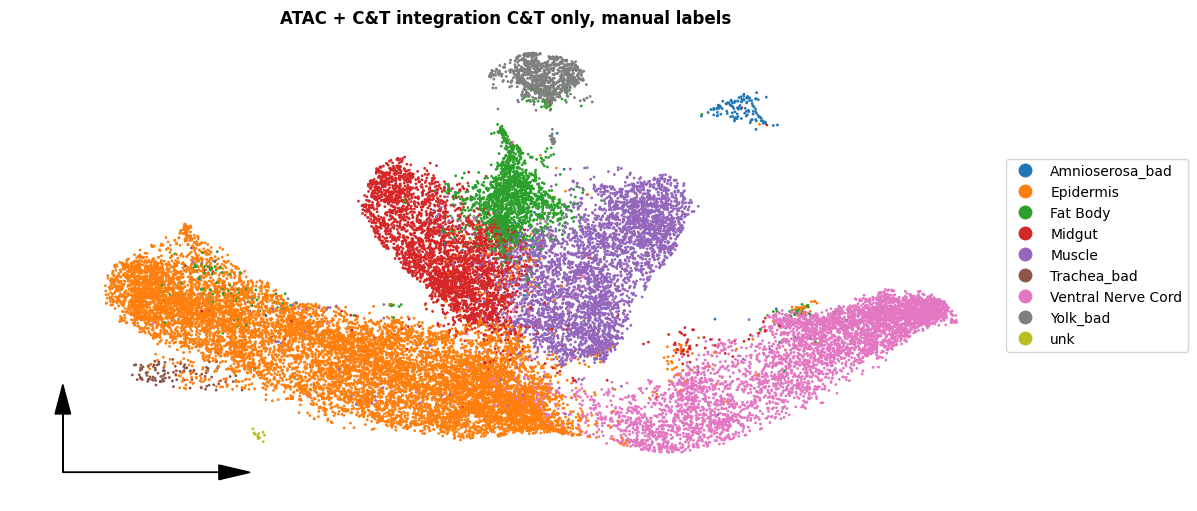

In [4]:
toolkit.pl.embedding2d(ctad, "X_umap", "label_own", size = 1, title = 'ATAC + C&T integration C&T only, manual labels')

### Get the original barcode formatting from .obs.index

In [5]:
ctad.obs['barcode'] = [idx[:-2] + '1' for idx in ctad.obs.index]
ctad.obs

,batch,meth_total_counts,meth_log_total_counts,acet_total_counts,acet_log_total_counts,exclude,timep,leiden_ms,label,leiden_glue,...,meth_binary_total_counts,meth_binary_log_total_counts,imputed_acet_total_counts,imputed_acet_log_total_counts,imputed_meth_total_counts,imputed_meth_log_total_counts,copied_data,leiden,label_own,barcode
AAACGAAAGAAGACTT-e1,batch1,144,4.976734,422,6.047372,False,8_10h,0,Foregut,6,...,134,4.905275,1700.000000,7.438972,1700.000000,7.438972,0.0,6,Epidermis,AAACGAAAGAAGACTT-1
AAACGAAAGCGTCAAG-e1,batch1,58,4.077537,256,5.549076,False,8_10h,1,Epidermis,4,...,52,3.970292,1700.000000,7.438972,1700.000000,7.438972,0.0,4,Epidermis,AAACGAAAGCGTCAAG-1
AAACGAACAACAACTC-e1,batch1,293,5.683580,1651,7.409742,False,8_10h,1,Muscle,0,...,174,5.164786,1700.000000,7.438972,1700.000000,7.438972,0.0,0,Muscle,AAACGAACAACAACTC-1
AAACGAACACACATTG-e1,batch1,110,4.709530,429,6.063785,False,8_10h,0,Pharnyx,10,...,104,4.653960,1700.000000,7.438972,1699.999878,7.438972,0.0,6,Epidermis,AAACGAACACACATTG-1
AAACGAACACCACCAG-e1,batch1,324,5.783825,1171,7.066467,False,8_10h,1,Brain,10,...,210,5.351858,1700.000122,7.438972,1700.000000,7.438972,0.0,6,Epidermis,AAACGAACACCACCAG-1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
TTTGTGTGTGAATGTA-l2,batch2,242,5.493061,394,5.978886,False,14_16h,0,Epidermis,9,...,174,5.164786,1700.000000,7.438972,1699.999878,7.438972,0.0,6,Epidermis,TTTGTGTGTGAATGTA-1
TTTGTGTGTGCTTGAT-l2,batch2,235,5.463832,476,6.167516,False,14_16h,3,Midgut,8,...,160,5.081404,1700.000000,7.438972,1700.000122,7.438972,0.0,8,Midgut,TTTGTGTGTGCTTGAT-1
TTTGTGTGTTTGCGAT-l2,batch2,180,5.198497,619,6.429719,False,14_16h,4,Midgut,1,...,150,5.017280,1700.000000,7.438972,1699.999878,7.438972,0.0,1,Midgut,TTTGTGTGTTTGCGAT-1
TTTGTGTTCCAACCTC-l2,batch2,84,4.442651,193,5.267858,False,14_16h,1,Pharnyx,10,...,78,4.369448,1699.999878,7.438972,1700.000000,7.438972,0.0,6,Epidermis,TTTGTGTTCCAACCTC-1


### Keep only the labels of interest

In [16]:
ctad.obs['label_own'].unique()

['Epidermis', 'Muscle', 'Midgut', 'Ventral Nerve Cord', 'Yolk_bad', 'Amnioserosa_bad', 'Trachea_bad', 'Fat Body', 'unk']
Categories (9, object): ['Amnioserosa_bad', 'Epidermis', 'Fat Body', 'Midgut', ..., 'Trachea_bad', 'Ventral Nerve Cord', 'Yolk_bad', 'unk']

In [14]:
labels_of_interest = [
    "Muscle", "Epidermis", "Midgut", "Ventral Nerve Cord", "Fat Body"
]

In [15]:
ctad2 = ctad[ctad.obs['label_own'].isin(labels_of_interest)]

In [17]:
ctad2.obs['label_own'].unique()

['Epidermis', 'Muscle', 'Midgut', 'Ventral Nerve Cord', 'Fat Body']
Categories (5, object): ['Epidermis', 'Fat Body', 'Midgut', 'Muscle', 'Ventral Nerve Cord']

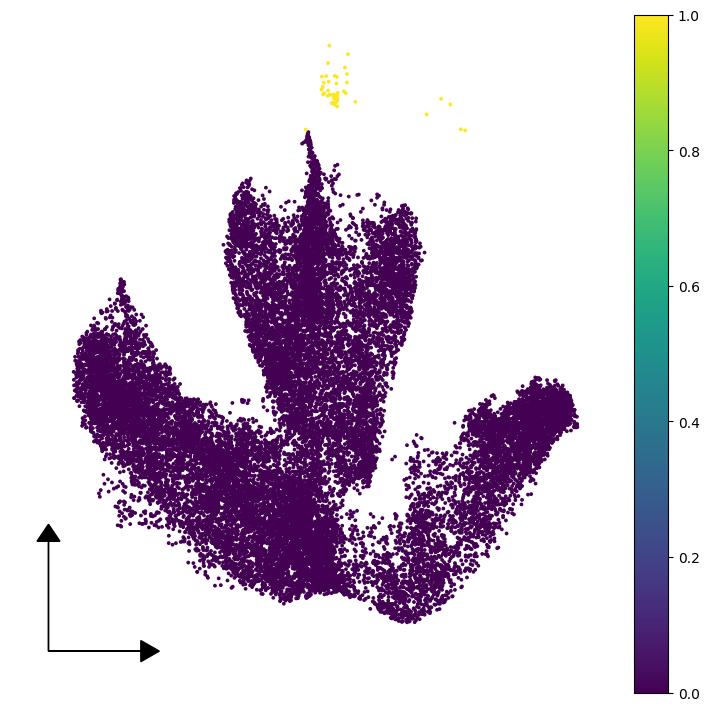

In [19]:
ctad2.obs['outside'] = ctad2.obsm['X_umap'][:,1] > 9.5
toolkit.pl.embedding2d(ctad2, 'X_umap', 'outside')

In [20]:
ctad2 = ctad2[~ctad2.obs['outside']]
del ctad2.obs['outside']

/Users/artemilin/Work/projects/scCandT/nbs/../toolkit-project/src/plotting/_helper.py:198: ImplicitModificationWarning: Trying to modify attribute `._uns` of view, initializing view as actual.
  self.adata.uns['colors_dict'] = colors_dict


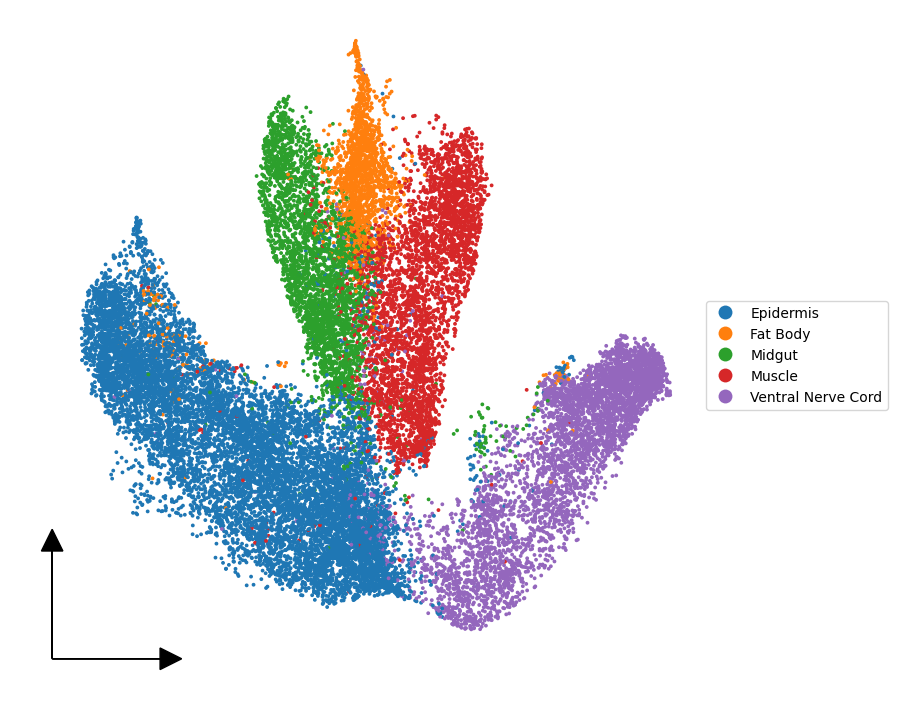

In [21]:
toolkit.pl.embedding2d(ctad2, "X_umap", 'label_own')

### Prepare CSV files with barcodes for each fragment file and cluster

In [22]:
# Ensure output directory exists
output_dir = "../pseudobulk_csv"
os.makedirs(output_dir, exist_ok=True)

# Iterate over all combinations of 'batch' and 'timep'
for (batch, timep), group in ctad2.obs.groupby(["batch", "timep"]):
    # Create a folder for the combination
    folder_path = os.path.join(output_dir, f"{batch}_{timep}")
    os.makedirs(folder_path, exist_ok=True)

    # Filter and save CSV files for each label of interest
    for label in labels_of_interest:
        # Filter the DataFrame for the current label
        filtered = group[group["label_own"] == label]

        # If there are rows, save them
        if not filtered.empty:
            safe_label = label.replace(" ", "_")
            csv_path = os.path.join(folder_path, f"{safe_label}.csv")
            filtered[["barcode"]].to_csv(csv_path, index=False, header=False)
            print(f"Saved {csv_path}")

Saved ../pseudobulk_csv/batch1_8_10h/Muscle.csv
Saved ../pseudobulk_csv/batch1_8_10h/Epidermis.csv
Saved ../pseudobulk_csv/batch1_8_10h/Midgut.csv
Saved ../pseudobulk_csv/batch1_8_10h/Ventral_Nerve_Cord.csv
Saved ../pseudobulk_csv/batch1_8_10h/Fat_Body.csv
Saved ../pseudobulk_csv/batch1_14_16h/Muscle.csv
Saved ../pseudobulk_csv/batch1_14_16h/Epidermis.csv
Saved ../pseudobulk_csv/batch1_14_16h/Midgut.csv
Saved ../pseudobulk_csv/batch1_14_16h/Ventral_Nerve_Cord.csv
Saved ../pseudobulk_csv/batch1_14_16h/Fat_Body.csv
Saved ../pseudobulk_csv/batch2_8_10h/Muscle.csv
Saved ../pseudobulk_csv/batch2_8_10h/Epidermis.csv
Saved ../pseudobulk_csv/batch2_8_10h/Midgut.csv
Saved ../pseudobulk_csv/batch2_8_10h/Ventral_Nerve_Cord.csv
Saved ../pseudobulk_csv/batch2_8_10h/Fat_Body.csv
Saved ../pseudobulk_csv/batch2_14_16h/Muscle.csv
Saved ../pseudobulk_csv/batch2_14_16h/Epidermis.csv
Saved ../pseudobulk_csv/batch2_14_16h/Midgut.csv
Saved ../pseudobulk_csv/batch2_14_16h/Ventral_Nerve_Cord.csv
Saved ../pseu

/var/folders/hg/9jt35chj7c93_pv8k103v49c0000gn/T/ipykernel_80539/811206784.py:6: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  for (batch, timep), group in ctad2.obs.groupby(["batch", "timep"]):


In [6]:
os.listdir("../pseudobulk_csv/batch1_8_10h/")

['Ventral_Nerve_Cord.csv',
 'Midgut.csv',
 'Epidermis.csv',
 'Fat_Body.csv',
 'Muscle.csv']

In [7]:
os.listdir("../scct_fragments/rep1/")

['emb8_10h_h3k27ac_1_fragments.tsv',
 'emb14_16h_h3k27me3_1_fragments.tsv',
 'emb8_10h_h3k27me3_1_fragments.tsv',
 'emb14_16h_h3k27ac_1_fragments.tsv']

In [8]:
os.listdir("../fragments/nanoct/rep1/")

FileNotFoundError: [Errno 2] No such file or directory: '../fragments/nanoct/rep1/'

In [9]:
chrom_sizes = [("chr2L", 23513712),
               ("chr2R", 25286936),
               ("chr3L", 28110227),
               ("chr3R", 32079331),
               ("chr4", 1348131),
               ("chrX", 23542271),
              ("chrY", 3667352)]  

In [24]:
!ls ..

Nanoscope_out_p29308.rJm5UwXc.tar.part nb_obso
Nanoscope_out_p29308.tar               nbs
cuttag_stats.csv                       p29308_fq
cuttag_stats.xlsx                      plots
debarcode.py                           plots_0
go_reg                                 pseudobulk
h5ad                                   pseudobulk_csv
metadata                               scct_fragments
nanoCT_rep2                            singlecell.csv
nanoCT_repmerg                         tables
nanoCT_repmerg2                        toolkit-project
nanoscope_out


In [25]:
!mkdir ../files_etc

In [27]:
!echo -e "chr2L\t23513712\nchr2R\t25286936\nchr3L\t28110227\nchr3R\t32079331\nchrX\t23542271" > ../files_etc/dm6.chrom.sizes


In [10]:
def read_fragment_file(bed_file):
    """Read a fragments file into a pandas DataFrame."""
    cols = ["chr", "start", "end", "read"]
    df = pd.read_csv(bed_file, sep="\t", header=None, usecols=[0, 1, 2, 3], names=cols, comment="#")
    df["chr"] = df["chr"].astype(str).apply(lambda x: x if x.startswith("chr") else f"chr{x}")
    return df

def filter_reads(bed_df, read_names_file):
    """Filter reads based on a read names file."""
    with open(read_names_file, "r") as f:
        valid_reads = set(line.strip() for line in f)

    # Assuming the BED file has a read name in column 3 (adjust if necessary)
    return bed_df[bed_df["read"].astype(str).isin(valid_reads)]

def create_bigwig(filtered_bed_path, windows_path, output_bw, chrom_sizes, norm = 1):
    """Convert the filtered BED data to a BigWig coverage track."""
    bedf = pybedtools.bedtool.BedTool(filtered_bed_path)
    bedsrt = bedf.sort()
    windf = pybedtools.bedtool.BedTool(windows_path)
    cov = windf.coverage(bedsrt)
    df = cov.to_dataframe(names=['chrom', 'start', 'end', 'depth', 'n', 'chromsize', 'fraction'])
    df = df[(df['depth'] > 0) & (df['chrom'].isin([i[0] for i in chrom_sizes]))]
    
    bw = pyBigWig.open(output_bw, "w")

    # Define chromosome sizes (adjust accordingly)
    bw.addHeader(chrom_sizes)

    bw.addEntries(
        df['chrom'].tolist(),
        starts = (df['start'] + 1).tolist(),
        ends = df['end'].tolist(),
        values = (df['depth']/norm).astype('float').tolist()
    )

    bw.close()


In [11]:
def absoluteFilePaths(directory):
    for dirpath,_,filenames in os.walk(directory):
        for f in filenames:
            yield os.path.abspath(os.path.join(dirpath, f))

In [12]:
frag_path = "../scct_fragments/"
frags = [i for i in absoluteFilePaths(frag_path)]

In [13]:
csv_dirs = os.listdir("../pseudobulk_csv")

In [14]:
csv_dirs.sort()

In [15]:
csv_dirs

['batch1_14_16h', 'batch1_8_10h', 'batch2_14_16h', 'batch2_8_10h']

In [16]:
frags.sort()
frags

['/Users/artemilin/Work/projects/Landscapes/scCandT/scct_fragments/rep1/emb14_16h_h3k27ac_1_fragments.tsv',
 '/Users/artemilin/Work/projects/Landscapes/scCandT/scct_fragments/rep1/emb14_16h_h3k27me3_1_fragments.tsv',
 '/Users/artemilin/Work/projects/Landscapes/scCandT/scct_fragments/rep1/emb8_10h_h3k27ac_1_fragments.tsv',
 '/Users/artemilin/Work/projects/Landscapes/scCandT/scct_fragments/rep1/emb8_10h_h3k27me3_1_fragments.tsv',
 '/Users/artemilin/Work/projects/Landscapes/scCandT/scct_fragments/rep2/emb_14_16h_h3k27ac_2_fragments.tsv',
 '/Users/artemilin/Work/projects/Landscapes/scCandT/scct_fragments/rep2/emb_14_16h_h3k27me3_2_fragments.tsv',
 '/Users/artemilin/Work/projects/Landscapes/scCandT/scct_fragments/rep2/emb_8_10h_h3k27ac_2_fragments.tsv',
 '/Users/artemilin/Work/projects/Landscapes/scCandT/scct_fragments/rep2/emb_8_10h_h3k27me3_2_fragments.tsv']

In [17]:
ps_dir = "../pseudobulk_csv"

In [18]:
csv_dirs = [os.path.abspath(os.path.join(ps_dir, f)) for f in os.listdir(ps_dir)]

In [19]:
csv_dirs.sort()
csv_dirs

['/Users/artemilin/Work/projects/Landscapes/scCandT/pseudobulk_csv/batch1_14_16h',
 '/Users/artemilin/Work/projects/Landscapes/scCandT/pseudobulk_csv/batch1_8_10h',
 '/Users/artemilin/Work/projects/Landscapes/scCandT/pseudobulk_csv/batch2_14_16h',
 '/Users/artemilin/Work/projects/Landscapes/scCandT/pseudobulk_csv/batch2_8_10h']

In [20]:
# Check that fragments and csv files are in the correct order
# 1. Frags
import re
pattern1 = r"(\d+_\d+).*?_(\d+)_"

# Extract values while maintaining order
extracted1 = [match.groups() for path in frags if (match := re.search(pattern1, path))]
# Flatten and get unique items while preserving order
unique_results1 = list(dict.fromkeys(extracted1))

pattern2 = r"batch([12]).*?_(\d+_\d+)h"
extracted2 = [match.groups()[::-1] for path in csv_dirs if (match := re.search(pattern2, path))]
assert(unique_results1 == extracted2)


In [21]:
os.listdir(csv_dirs[0])

['Ventral_Nerve_Cord.csv',
 'Midgut.csv',
 'Epidermis.csv',
 'Fat_Body.csv',
 'Muscle.csv']

In [22]:
frags_csv = {}
for i in range(0,4):
    frags_csv[csv_dirs[i]] = frags[(i*2):(i*2 + 2)]

In [23]:
frags_csv

{'/Users/artemilin/Work/projects/Landscapes/scCandT/pseudobulk_csv/batch1_14_16h': ['/Users/artemilin/Work/projects/Landscapes/scCandT/scct_fragments/rep1/emb14_16h_h3k27ac_1_fragments.tsv',
  '/Users/artemilin/Work/projects/Landscapes/scCandT/scct_fragments/rep1/emb14_16h_h3k27me3_1_fragments.tsv'],
 '/Users/artemilin/Work/projects/Landscapes/scCandT/pseudobulk_csv/batch1_8_10h': ['/Users/artemilin/Work/projects/Landscapes/scCandT/scct_fragments/rep1/emb8_10h_h3k27ac_1_fragments.tsv',
  '/Users/artemilin/Work/projects/Landscapes/scCandT/scct_fragments/rep1/emb8_10h_h3k27me3_1_fragments.tsv'],
 '/Users/artemilin/Work/projects/Landscapes/scCandT/pseudobulk_csv/batch2_14_16h': ['/Users/artemilin/Work/projects/Landscapes/scCandT/scct_fragments/rep2/emb_14_16h_h3k27ac_2_fragments.tsv',
  '/Users/artemilin/Work/projects/Landscapes/scCandT/scct_fragments/rep2/emb_14_16h_h3k27me3_2_fragments.tsv'],
 '/Users/artemilin/Work/projects/Landscapes/scCandT/pseudobulk_csv/batch2_8_10h': ['/Users/arte

### Make 50 nt genomic windows on dm6 genome

In [27]:
a = pybedtools.bedtool.BedTool()
b = a.makewindows(genome = "dm6", w = 50)

In [28]:
b.saveas("../bed/dm6.chromios.bed")

<BedTool(../bed/dm6.chromios.bed)>

## Start producing pseudobulk profiles bigwigs
### Pool together fragment files from both replicates for separate modalities and time points

In [54]:
!mkdir ../bed_wt

In [57]:
frags_csv.keys()

dict_keys(['/Users/artemilin/Work/projects/Landscapes/scCandT/pseudobulk_csv/batch1_14_16h', '/Users/artemilin/Work/projects/Landscapes/scCandT/pseudobulk_csv/batch1_8_10h', '/Users/artemilin/Work/projects/Landscapes/scCandT/pseudobulk_csv/batch2_14_16h', '/Users/artemilin/Work/projects/Landscapes/scCandT/pseudobulk_csv/batch2_8_10h'])

In [59]:
import os
import pandas as pd

# Dictionary to store bed files by time point, modality, and cluster
bed_files = {}
# Dictionary to store total number of fragmoids per time point and modalitet
totals = {
    ('8_10h', 'h3k27ac'): 0,
    ('8_10h', 'h3k27me3'): 0,
    ('14_16h', 'h3k27ac'): 0,
    ('14_16h', 'h3k27me3'): 0
}
# Dictionary for normalization factors
fragkeys = list(frags_csv.keys())

for csvf in frags_csv.keys():
    print(csvf)
    
    # 1. H3K27ac
    ac_frag_p = next((s for s in frags_csv[csvf] if "h3k27ac" in s), None)
    ac_base = os.path.basename(ac_frag_p).replace("_fragments.tsv", "")
    ac_frag = read_fragment_file(ac_frag_p)

    # 2. H3K27me3
    meth_frag_p = next((s for s in frags_csv[csvf] if "h3k27me" in s), None)
    meth_base = os.path.basename(meth_frag_p).replace("_fragments.tsv", "")
    meth_frag = read_fragment_file(meth_frag_p)

    # Extract time point
    time_point = "8_10h" if "8_10h" in csvf else "14_16h"
    # Adjust nfrags
    totals[(time_point, "h3k27ac")]  += len(ac_frag)
    totals[(time_point, "h3k27me3")] += len(meth_frag)


    for read_l_base in os.listdir(csvf):
        cluster_bw = read_l_base.replace("csv", "bw")
        read_list = os.path.join(csvf, read_l_base)

        # Extract cluster identifier
        cluster_id = os.path.splitext(read_l_base)[0]

        for modality, frag, base in [("h3k27ac", ac_frag, ac_base), ("h3k27me3", meth_frag, meth_base)]:
            temp_bed = f"../bed_wt/{base}_{cluster_id}_temp.bed"
            filtered_reads = filter_reads(frag, read_list)
            filtered_reads.iloc[:, 0:3].to_csv(temp_bed, sep="\t", index=False, header=False)
            
            # Store bed files by (time_point, modality, cluster)
            key = (time_point, modality, cluster_id)
            if key not in bed_files:
                bed_files[key] = []
            bed_files[key].append(temp_bed)

    # print([ac_frag_p, meth_frag_p])



/Users/artemilin/Work/projects/Landscapes/scCandT/pseudobulk_csv/batch1_14_16h
/Users/artemilin/Work/projects/Landscapes/scCandT/pseudobulk_csv/batch1_8_10h
/Users/artemilin/Work/projects/Landscapes/scCandT/pseudobulk_csv/batch2_14_16h
/Users/artemilin/Work/projects/Landscapes/scCandT/pseudobulk_csv/batch2_8_10h


In [29]:
totals

{('8_10h', 'h3k27ac'): 17585263,
 ('8_10h', 'h3k27me3'): 7189953,
 ('14_16h', 'h3k27ac'): 4637063,
 ('14_16h', 'h3k27me3'): 3279273}

In [31]:
!mkdir ../bw_norm

### Normalize bigwig profiles on cluster size at a given time point
Normalization coefficient is equal to (cluster_size)/1000, because the largest cluster consists of ~8000 cells
For no normalization, don't use norm parameter in create_bigwig function or set it to 1.

In [32]:
# Folder name for saving the outputs
bwf = 'bw_norm'
# Merge and create BigWig files
for (time_point, modality, cluster_id), beds in bed_files.items():
    merged_bed = f"../bed/{time_point}_{modality}_{cluster_id}_merged.bed"
    merged_bw = f"../{bwf}/{time_point}_{modality}_{cluster_id}.bw"

    # Merge BED files
    bed_dfs = [pd.read_csv(b, sep="\t", header=None) for b in beds]
    merged_df = pd.concat(bed_dfs, ignore_index=True)
    merged_df.to_csv(merged_bed, sep="\t", index=False, header=False)

    # Get normalization coefficient
    csv_walk = [list(os.walk(k)) for k in fragkeys if time_point in k]
    csv_path = [os.path.join(dirpath, file) for batch in csv_walk for dirpath, _, files in batch for file in files]
    bc_cluster = [k for k in csv_path if cluster_id in k]
    normc = sum(sum(1 for _ in open(file, "r")) for file in bc_cluster)/1000
    print(normc)

    # Create BigWig
    create_bigwig(merged_bed, "../bed/dm6.chromios.bed", merged_bw, chrom_sizes, norm=normc)

3.14
3.14
1.239
1.239
3.352
3.352
1.135
1.135
1.618
1.618
1.972
1.972
2.276
2.276
8.314
8.314
0.846
0.846
2.506
2.506


### Normalize bigwig profiles on the number of fragments at a given time point
Normalization coefficient is equal to ()/1000, because the largest cluster consists of ~8000 cells
For no normalization, don't use norm parameter in create_bigwig function or set it to 1.

In [4]:
!mkdir ../bw_norm_by_frag

In [64]:
import pickle

In [65]:
pickle.dump

<function _pickle.dump(obj, file, protocol=None, *, fix_imports=True, buffer_callback=None)>

In [66]:
!mkdir ../pickle

In [67]:
with open("../pickle/fragscsv_wt.pickle", 'wb') as f:
     pickle.dump(frags_csv, f)

In [37]:
bed_files.items()


dict_items([(('14_16h', 'h3k27ac', 'Ventral_Nerve_Cord'), ['../bed/emb14_16h_h3k27ac_1__Ventral_Nerve_Cord_temp.bed', '../bed/emb_14_16h_h3k27ac_2__Ventral_Nerve_Cord_temp.bed']), (('14_16h', 'h3k27me3', 'Ventral_Nerve_Cord'), ['../bed/emb14_16h_h3k27me3_1__Ventral_Nerve_Cord_temp.bed', '../bed/emb_14_16h_h3k27me3_2__Ventral_Nerve_Cord_temp.bed']), (('14_16h', 'h3k27ac', 'Midgut'), ['../bed/emb14_16h_h3k27ac_1__Midgut_temp.bed', '../bed/emb_14_16h_h3k27ac_2__Midgut_temp.bed']), (('14_16h', 'h3k27me3', 'Midgut'), ['../bed/emb14_16h_h3k27me3_1__Midgut_temp.bed', '../bed/emb_14_16h_h3k27me3_2__Midgut_temp.bed']), (('14_16h', 'h3k27ac', 'Epidermis'), ['../bed/emb14_16h_h3k27ac_1__Epidermis_temp.bed', '../bed/emb_14_16h_h3k27ac_2__Epidermis_temp.bed']), (('14_16h', 'h3k27me3', 'Epidermis'), ['../bed/emb14_16h_h3k27me3_1__Epidermis_temp.bed', '../bed/emb_14_16h_h3k27me3_2__Epidermis_temp.bed']), (('14_16h', 'h3k27ac', 'Fat_Body'), ['../bed/emb14_16h_h3k27ac_1__Fat_Body_temp.bed', '../bed/emb

In [42]:
# Folder name for saving the outputs
bwf = 'bw_norm_by_frag'
# Merge and create BigWig files
for (time_point, modality, cluster_id), beds in bed_files.items():
    merged_bed = f"../bed/{time_point}_{modality}_{cluster_id}_merged.bed"
    merged_bw = f"../{bwf}/{time_point}_{modality}_{cluster_id}.bw"

    # Merge BED files
    bed_dfs = [pd.read_csv(b, sep="\t", header=None) for b in beds]
    merged_df = pd.concat(bed_dfs, ignore_index=True)
    merged_df.to_csv(merged_bed, sep="\t", index=False, header=False)

    # Get normalization coefficient
    csv_walk = [list(os.walk(k)) for k in fragkeys if time_point in k]
    csv_path = [os.path.join(dirpath, file) for batch in csv_walk for dirpath, _, files in batch for file in files]
    bc_cluster = [k for k in csv_path if cluster_id in k]
    normc = sum(1 for _ in open(merged_bed, "r"))/1000000
    print(normc)

    # Create BigWig
    create_bigwig(merged_bed, "../bed/dm6.chromios.bed", merged_bw, chrom_sizes, norm=normc)

0.992939
0.59898
0.42659
0.241591
0.871346
0.650127
0.257455
0.220514
0.433174
0.293162
1.208114
0.451417
1.499307
0.47214
5.342272
1.843822
0.372214
0.311919
1.515462
0.532723


### Cluster size x Fragment number normalization

In [60]:
!mkdir ../bw_norm_by_csfrag_wt

In [61]:
bed_files.items()


dict_items([(('14_16h', 'h3k27ac', 'Ventral_Nerve_Cord'), ['../bed_wt/emb14_16h_h3k27ac_1_Ventral_Nerve_Cord_temp.bed', '../bed_wt/emb_14_16h_h3k27ac_2_Ventral_Nerve_Cord_temp.bed']), (('14_16h', 'h3k27me3', 'Ventral_Nerve_Cord'), ['../bed_wt/emb14_16h_h3k27me3_1_Ventral_Nerve_Cord_temp.bed', '../bed_wt/emb_14_16h_h3k27me3_2_Ventral_Nerve_Cord_temp.bed']), (('14_16h', 'h3k27ac', 'Midgut'), ['../bed_wt/emb14_16h_h3k27ac_1_Midgut_temp.bed', '../bed_wt/emb_14_16h_h3k27ac_2_Midgut_temp.bed']), (('14_16h', 'h3k27me3', 'Midgut'), ['../bed_wt/emb14_16h_h3k27me3_1_Midgut_temp.bed', '../bed_wt/emb_14_16h_h3k27me3_2_Midgut_temp.bed']), (('14_16h', 'h3k27ac', 'Epidermis'), ['../bed_wt/emb14_16h_h3k27ac_1_Epidermis_temp.bed', '../bed_wt/emb_14_16h_h3k27ac_2_Epidermis_temp.bed']), (('14_16h', 'h3k27me3', 'Epidermis'), ['../bed_wt/emb14_16h_h3k27me3_1_Epidermis_temp.bed', '../bed_wt/emb_14_16h_h3k27me3_2_Epidermis_temp.bed']), (('14_16h', 'h3k27ac', 'Fat_Body'), ['../bed_wt/emb14_16h_h3k27ac_1_Fat_B

In [62]:
# Folder name for saving the outputs
bwf = 'bw_norm_by_csfrag_wt'
# Merge and create BigWig files
for (time_point, modality, cluster_id), beds in bed_files.items():
    merged_bed = f"../bed/{time_point}_{modality}_{cluster_id}_merged.bed"
    merged_bw = f"../{bwf}/{time_point}_{modality}_{cluster_id}.bw"

    # Merge BED files
    bed_dfs = [pd.read_csv(b, sep="\t", header=None) for b in beds]
    merged_df = pd.concat(bed_dfs, ignore_index=True)
    merged_df.to_csv(merged_bed, sep="\t", index=False, header=False)

    # Get normalization coefficient
    csv_walk = [list(os.walk(k)) for k in fragkeys if time_point in k]
    csv_path = [os.path.join(dirpath, file) for batch in csv_walk for dirpath, _, files in batch for file in files]
    bc_cluster = [k for k in csv_path if cluster_id in k]
    cls = sum(sum(1 for _ in open(file, "r")) for file in bc_cluster)
    frn = sum(1 for _ in open(merged_bed, "r"))
    normc = (cls*frn)/10e9
    print(normc)

    # Create BigWig
    create_bigwig(merged_bed, "../bed/dm6.chromios.bed", merged_bw, chrom_sizes, norm=normc)

0.311782846
0.18807972
0.052811842
0.0299089658
0.2920751792
0.2179225704
0.028937942
0.0247857736
0.0700875532
0.0474336116
0.2382400808
0.0890194324
0.3400428276
0.107081352
4.4410307136
1.5327692286
0.030335441
0.0254213985
0.3797747772
0.1335003838


### Normalize on total number of fragments

In [31]:
%mkdir ../bw_norm_totfr_wt

mkdir: ../bw_norm_totfr_wt: File exists


In [33]:
# Folder name for saving the outputs
bwf = 'bw_norm_totfr_wt'
# Merge and create BigWig files
for (time_point, modality, cluster_id), beds in bed_files.items():
    merged_bed = f"../bed/{time_point}_{modality}_{cluster_id}_merged.bed"
    merged_bw = f"../{bwf}/WT_nbyTotFr{time_point}_{modality}_{cluster_id}.bw"

    # Merge BED files
    bed_dfs = [pd.read_csv(b, sep="\t", header=None) for b in beds]
    merged_df = pd.concat(bed_dfs, ignore_index=True)
    merged_df.to_csv(merged_bed, sep="\t", index=False, header=False)

    # Get normalization coefficient
    csv_walk = [list(os.walk(k)) for k in fragkeys]
    print(csv_walk)
    csv_path = [os.path.join(dirpath, file) for batch in csv_walk for dirpath, _, files in batch for file in files]
    bc_cluster = [k for k in csv_path if cluster_id in k]
    normc = totals[(time_point, modality)]/1000000
    
    print(normc)

    # Create BigWig
    create_bigwig(merged_bed, "../bed/dm6.chromios.bed", merged_bw, chrom_sizes, norm=normc)

[[('/Users/artemilin/Work/projects/Landscapes/scCandT/pseudobulk_csv/batch1_14_16h', [], ['Ventral_Nerve_Cord.csv', 'Midgut.csv', 'Epidermis.csv', 'Fat_Body.csv', 'Muscle.csv'])], [('/Users/artemilin/Work/projects/Landscapes/scCandT/pseudobulk_csv/batch1_8_10h', [], ['Ventral_Nerve_Cord.csv', 'Midgut.csv', 'Epidermis.csv', 'Fat_Body.csv', 'Muscle.csv'])], [('/Users/artemilin/Work/projects/Landscapes/scCandT/pseudobulk_csv/batch2_14_16h', [], ['Ventral_Nerve_Cord.csv', 'Midgut.csv', 'Epidermis.csv', 'Fat_Body.csv', 'Muscle.csv'])], [('/Users/artemilin/Work/projects/Landscapes/scCandT/pseudobulk_csv/batch2_8_10h', [], ['Ventral_Nerve_Cord.csv', 'Midgut.csv', 'Epidermis.csv', 'Fat_Body.csv', 'Muscle.csv'])]]
4.637063
[[('/Users/artemilin/Work/projects/Landscapes/scCandT/pseudobulk_csv/batch1_14_16h', [], ['Ventral_Nerve_Cord.csv', 'Midgut.csv', 'Epidermis.csv', 'Fat_Body.csv', 'Muscle.csv'])], [('/Users/artemilin/Work/projects/Landscapes/scCandT/pseudobulk_csv/batch1_8_10h', [], ['Ventral

### Do, but separately for replicates

In [46]:
ac_base

'emb_8_10h_h3k27ac_2_'

In [49]:
# Dictionary to store bed files by time point, modality, replicate, and cluster
# key: (time_point, modality, rep_id, cluster_id) -> list of bed paths (one per replicate file you create)
bed_files = defaultdict(list)

# Dictionary to store total number of fragments **per time_point × modality × replicate**
totals = {}  # key: (time_point, modality, rep_id) -> int

fragkeys = list(frags_csv.keys())  # your existing dict: {replicate_folder: [frag_paths...]}

def count_lines(path):
    # Faster + memory-light line counter (gz or not)
    if path.endswith(".gz"):
        import gzip
        with gzip.open(path, "rt") as f:
            return sum(1 for _ in f)
    else:
        with open(path, "r") as f:
            return sum(1 for _ in f)

for csvf in frags_csv.keys():
    # Derive replicate id from folder name
    rep_id = os.path.basename(os.path.normpath(csvf))

    # 1) get fragment files per modality for THIS replicate
    ac_frag_p   = next((s for s in frags_csv[csvf] if "h3k27ac"  in s), None)
    meth_frag_p = next((s for s in frags_csv[csvf] if "h3k27me" in s), None)

    if ac_frag_p is None or meth_frag_p is None:
        raise FileNotFoundError(f"Missing h3k27ac or h3k27me3 fragments for replicate {rep_id}")

    # (Optional) your original loader; for totals we only need counts
    # ac_frag = read_fragment_file(ac_frag_p)
    # meth_frag = read_fragment_file(meth_frag_p)

    # Extract time point from path
    time_point = "8_10h" if "8_10h" in csvf else "14_16h"

    # --- TOTALS PER REPLICATE (not pooled) ---
    n_ac_total   = count_lines(ac_frag_p)
    n_meth_total = count_lines(meth_frag_p)
    totals[(time_point, "h3k27ac",  rep_id)] = n_ac_total
    totals[(time_point, "h3k27me3", rep_id)] = n_meth_total

    # Bases used to name temp beds
    ac_base   = os.path.basename(ac_frag_p).replace("_fragments.tsv", "")
    meth_base = os.path.basename(meth_frag_p).replace("_fragments.tsv", "")

    # For each cluster list in this replicate folder, make a temp BED per modality
    for read_l_base in os.listdir(csvf):
        if not read_l_base.endswith(".csv"):
            continue
        read_list = os.path.join(csvf, read_l_base)
        cluster_id = os.path.splitext(read_l_base)[0]

        # Filter per modality and write 3-col BEDs (as you did)
        # Using your existing helpers:
        ac_frag_df   = read_fragment_file(ac_frag_p)
        meth_frag_df = read_fragment_file(meth_frag_p)

        filtered_ac   = filter_reads(ac_frag_df,   read_list)
        filtered_meth = filter_reads(meth_frag_df, read_list)

        ac_temp_bed   = f"../bed/{ac_base}_{cluster_id}_temp.bed"
        meth_temp_bed = f"../bed/{meth_base}_{cluster_id}_temp.bed"

        filtered_ac.iloc[:,   0:3].to_csv(ac_temp_bed,   sep="\t", index=False, header=False)
        filtered_meth.iloc[:, 0:3].to_csv(meth_temp_bed, sep="\t", index=False, header=False)

        # Store by **replicate** so we can fetch the correct total later
        bed_files[(time_point, "h3k27ac",  rep_id, cluster_id)].append(ac_temp_bed)
        bed_files[(time_point, "h3k27me3", rep_id, cluster_id)].append(meth_temp_bed)


In [50]:
bed_files

defaultdict(list,
            {('14_16h',
              'h3k27ac',
              'batch1_14_16h',
              'Ventral_Nerve_Cord'): ['../bed/emb14_16h_h3k27ac_1_Ventral_Nerve_Cord_temp.bed'],
             ('14_16h',
              'h3k27me3',
              'batch1_14_16h',
              'Ventral_Nerve_Cord'): ['../bed/emb14_16h_h3k27me3_1_Ventral_Nerve_Cord_temp.bed'],
             ('14_16h',
              'h3k27ac',
              'batch1_14_16h',
              'Midgut'): ['../bed/emb14_16h_h3k27ac_1_Midgut_temp.bed'],
             ('14_16h',
              'h3k27me3',
              'batch1_14_16h',
              'Midgut'): ['../bed/emb14_16h_h3k27me3_1_Midgut_temp.bed'],
             ('14_16h',
              'h3k27ac',
              'batch1_14_16h',
              'Epidermis'): ['../bed/emb14_16h_h3k27ac_1_Epidermis_temp.bed'],
             ('14_16h',
              'h3k27me3',
              'batch1_14_16h',
              'Epidermis'): ['../bed/emb14_16h_h3k27me3_1_Epidermis_temp.bed']

In [52]:
from pathlib import Path

In [53]:
# Folder name for saving the outputs
bwf = 'bw_norm_totfr_wt_seprep'
os.makedirs(f"../{bwf}", exist_ok=True)

# Create BigWig files WITHOUT merging.
# Normalize each cluster BED by the **replicate-level** total fragments (time_point, modality, rep_id).
for (time_point, modality, rep_id, cluster_id), beds in bed_files.items():
    # Normalization coefficient: CPM by total fragments in the **source replicate**
    n_total = totals[(time_point, modality, rep_id)]
    if n_total == 0:
        print(f"[SKIP] zero total fragments for {(time_point, modality, rep_id)}")
        continue
    normc = 1_000_000 / n_total
    print(f"[INFO] norm={normc:.6f} using total fragments {n_total} for {(time_point, modality, rep_id)}")

    # Build a BigWig for **each** replicate bed (no merging)
    for bed in beds:
        bed = Path(bed)
        # Make output name explicit so replicates don’t collide
        base_tag = bed.name.replace("_temp.bed", "").replace(".bed", "")
        out_bw = f"../{bwf}/WT_cpmTotFr_{time_point}_{modality}_{rep_id}_{cluster_id}_{base_tag}.bw"

        create_bigwig(
            str(bed),
            "../bed/dm6.chromios.bed",
            out_bw,
            chrom_sizes,
            norm=normc
        )


[INFO] norm=0.372047 using total fragments 2687832 for ('14_16h', 'h3k27ac', 'batch1_14_16h')
[INFO] norm=0.534877 using total fragments 1869590 for ('14_16h', 'h3k27me3', 'batch1_14_16h')
[INFO] norm=0.372047 using total fragments 2687832 for ('14_16h', 'h3k27ac', 'batch1_14_16h')
[INFO] norm=0.534877 using total fragments 1869590 for ('14_16h', 'h3k27me3', 'batch1_14_16h')
[INFO] norm=0.372047 using total fragments 2687832 for ('14_16h', 'h3k27ac', 'batch1_14_16h')
[INFO] norm=0.534877 using total fragments 1869590 for ('14_16h', 'h3k27me3', 'batch1_14_16h')
[INFO] norm=0.372047 using total fragments 2687832 for ('14_16h', 'h3k27ac', 'batch1_14_16h')
[INFO] norm=0.534877 using total fragments 1869590 for ('14_16h', 'h3k27me3', 'batch1_14_16h')
[INFO] norm=0.372047 using total fragments 2687832 for ('14_16h', 'h3k27ac', 'batch1_14_16h')
[INFO] norm=0.534877 using total fragments 1869590 for ('14_16h', 'h3k27me3', 'batch1_14_16h')
[INFO] norm=0.089590 using total fragments 11161956 for

In [ ]:
# Folder name for saving the outputs

# Merge and create BigWig files
for (time_point, modality, cluster_id), beds in bed_files.items():
    bw_1 = f"../{bwf}/WT_nbyTotFr{time_point}_{modality}_{cluster_id}_rep1.bw"
    bw_2 = f"../{bwf}/WT_nbyTotFr{time_point}_{modality}_{cluster_id}_rep2.bw"
    print([modality, cluster_id, beds[0], beds[1]])
    # Merge BED files
    bed_dfs = [pd.read_csv(b, sep="\t", header=None) for b in beds]
    merged_df = pd.concat(bed_dfs, ignore_index=True)
    merged_df.to_csv(merged_bed, sep="\t", index=False, header=False)

    # Get normalization coefficient
    csv_walk = [list(os.walk(k)) for k in fragkeys]
    print(csv_walk)
    csv_path = [os.path.join(dirpath, file) for batch in csv_walk for dirpath, _, files in batch for file in files]
    bc_cluster = [k for k in csv_path if cluster_id in k]
    normc = totals[(time_point, modality)]/1000000
    
    print(normc)

    # Create BigWig
    create_bigwig(merged_bed, "../bed/dm6.chromios.bed", merged_bw, chrom_sizes, norm=normc)

[[('/Users/artemilin/Work/projects/Landscapes/scCandT/pseudobulk_csv/batch1_14_16h', [], ['Ventral_Nerve_Cord.csv', 'Midgut.csv', 'Epidermis.csv', 'Fat_Body.csv', 'Muscle.csv'])], [('/Users/artemilin/Work/projects/Landscapes/scCandT/pseudobulk_csv/batch1_8_10h', [], ['Ventral_Nerve_Cord.csv', 'Midgut.csv', 'Epidermis.csv', 'Fat_Body.csv', 'Muscle.csv'])], [('/Users/artemilin/Work/projects/Landscapes/scCandT/pseudobulk_csv/batch2_14_16h', [], ['Ventral_Nerve_Cord.csv', 'Midgut.csv', 'Epidermis.csv', 'Fat_Body.csv', 'Muscle.csv'])], [('/Users/artemilin/Work/projects/Landscapes/scCandT/pseudobulk_csv/batch2_8_10h', [], ['Ventral_Nerve_Cord.csv', 'Midgut.csv', 'Epidermis.csv', 'Fat_Body.csv', 'Muscle.csv'])]]
4.637063
[[('/Users/artemilin/Work/projects/Landscapes/scCandT/pseudobulk_csv/batch1_14_16h', [], ['Ventral_Nerve_Cord.csv', 'Midgut.csv', 'Epidermis.csv', 'Fat_Body.csv', 'Muscle.csv'])], [('/Users/artemilin/Work/projects/Landscapes/scCandT/pseudobulk_csv/batch1_8_10h', [], ['Ventral

### Normalize by both total fragments and cluster sizes

In [34]:
%mkdir ../bw_norm_totfrcs_wt

In [35]:
# Folder name for saving the outputs
bwf = 'bw_norm_totfrcs_wt'
# Merge and create BigWig files
for (time_point, modality, cluster_id), beds in bed_files.items():
    merged_bed = f"../bed/{time_point}_{modality}_{cluster_id}_merged.bed"
    merged_bw = f"../{bwf}/WT_nbyTotFr{time_point}_{modality}_{cluster_id}.bw"

    # Merge BED files
    bed_dfs = [pd.read_csv(b, sep="\t", header=None) for b in beds]
    merged_df = pd.concat(bed_dfs, ignore_index=True)
    merged_df.to_csv(merged_bed, sep="\t", index=False, header=False)

    # Get normalization coefficient
    csv_walk = [list(os.walk(k)) for k in fragkeys]
    print(csv_walk)
    csv_path = [os.path.join(dirpath, file) for batch in csv_walk for dirpath, _, files in batch for file in files]
    bc_cluster = [k for k in csv_path if cluster_id in k]
    normc = sum(sum(1 for _ in open(file, "r")) for file in bc_cluster)*totals[(time_point, modality)]/1000000000

    print(normc)

    # Create BigWig
    create_bigwig(merged_bed, "../bed/dm6.chromios.bed", merged_bw, chrom_sizes, norm=normc)

[[('/Users/artemilin/Work/projects/Landscapes/scCandT/pseudobulk_csv/batch1_14_16h', [], ['Ventral_Nerve_Cord.csv', 'Midgut.csv', 'Epidermis.csv', 'Fat_Body.csv', 'Muscle.csv'])], [('/Users/artemilin/Work/projects/Landscapes/scCandT/pseudobulk_csv/batch1_8_10h', [], ['Ventral_Nerve_Cord.csv', 'Midgut.csv', 'Epidermis.csv', 'Fat_Body.csv', 'Muscle.csv'])], [('/Users/artemilin/Work/projects/Landscapes/scCandT/pseudobulk_csv/batch2_14_16h', [], ['Ventral_Nerve_Cord.csv', 'Midgut.csv', 'Epidermis.csv', 'Fat_Body.csv', 'Muscle.csv'])], [('/Users/artemilin/Work/projects/Landscapes/scCandT/pseudobulk_csv/batch2_8_10h', [], ['Ventral_Nerve_Cord.csv', 'Midgut.csv', 'Epidermis.csv', 'Fat_Body.csv', 'Muscle.csv'])]]
23.704666056
[[('/Users/artemilin/Work/projects/Landscapes/scCandT/pseudobulk_csv/batch1_14_16h', [], ['Ventral_Nerve_Cord.csv', 'Midgut.csv', 'Epidermis.csv', 'Fat_Body.csv', 'Muscle.csv'])], [('/Users/artemilin/Work/projects/Landscapes/scCandT/pseudobulk_csv/batch1_8_10h', [], ['Ven

## Some examples of pybedtools workflow

In [35]:
a = pybedtools.bedtool.BedTool("../bed/emb8101ac_epidermis.bed")
b = a.genome_coverage(bg=True, genome='dm6')

In [38]:
b.moveto("../bed/emb8101ac_epidermis_cov.bedgraph")

<BedTool(../bed/emb8101ac_epidermis_cov.bedgraph)>

In [47]:
c = pybedtools.bedtool.BedTool("../bed/emb8101ac_epidermis.bed")
d = b.coverage(c)

In [64]:
df = d.to_dataframe(names=['chrom', 'start', 'end', 'depth', 'n', 'chromsize', 'fraction'])
df = df[(df['depth'] > 0) & (df['chrom'].isin([i[0] for i in chrom_sizes]))]

In [93]:
bw = pyBigWig.open("../bw/emb8101ac_epi.bw", "w")

# Define chromosome sizes (adjust accordingly)
bw.addHeader(chrom_sizes)
bw.addEntries(
    df['chrom'].tolist(),
    starts = (df['start'] + 1).tolist(),
    ends = df['end'].tolist(),
    values = df['depth'].astype('float').tolist()
)


bw.close()

In [89]:
(df['end'] + 1).tolist()

[5251,
 5301,
 5351,
 5401,
 5451,
 5501,
 5551,
 5601,
 5651,
 5701,
 5851,
 5901,
 5951,
 6001,
 6051,
 6101,
 6151,
 6201,
 6251,
 6301,
 6351,
 6401,
 6451,
 6501,
 6551,
 6601,
 6651,
 6701,
 6751,
 6801,
 6851,
 6901,
 6951,
 7301,
 7351,
 7401,
 7451,
 7501,
 7551,
 7601,
 7651,
 7701,
 7751,
 7801,
 7851,
 7901,
 7951,
 8001,
 8051,
 8101,
 8201,
 8251,
 8301,
 8351,
 8401,
 8451,
 8501,
 8551,
 8601,
 8651,
 8701,
 8751,
 8801,
 8851,
 8901,
 8951,
 9001,
 9051,
 9101,
 9151,
 9201,
 9251,
 9301,
 9351,
 9401,
 9451,
 9501,
 9551,
 9601,
 9651,
 9701,
 9751,
 9801,
 9851,
 9901,
 10001,
 10251,
 10301,
 10351,
 10401,
 10451,
 10501,
 10651,
 10701,
 10751,
 10801,
 10851,
 10901,
 10951,
 11001,
 11051,
 11101,
 11151,
 11201,
 11251,
 11301,
 11351,
 11401,
 11451,
 11501,
 11551,
 11601,
 11651,
 11751,
 11801,
 11851,
 11901,
 11951,
 12001,
 12051,
 12101,
 12151,
 12201,
 12251,
 12301,
 12351,
 12401,
 12451,
 12501,
 12551,
 12601,
 12651,
 12701,
 12751,
 12801,
 1285

In [79]:
df

,chrom,start,end,depth,n,chromsize,fraction
104,chr2L,5200,5250,1,6,50,0.12
105,chr2L,5250,5300,1,50,50,1.00
106,chr2L,5300,5350,1,50,50,1.00
107,chr2L,5350,5400,1,50,50,1.00
108,chr2L,5400,5450,1,50,50,1.00
...,...,...,...,...,...,...,...
2857863,chrY,3652900,3652950,7,24,50,0.48
2857932,chrY,3656350,3656400,1,11,50,0.22
2857933,chrY,3656400,3656450,1,14,50,0.28
2857936,chrY,3656550,3656600,1,3,50,0.06


In [ ]:
for chrom, group in df.groupby("chrom"):
    starts = group["start"].tolist()
    ends = group["end"].tolist()
    scores = group["depth"].astype("float").tolist()
    bw.addEntries(chrom, starts=starts, ends=ends, values=scores)

In [ ]:
dm6={"X":23542271,
"2L":23513712,
"2R":25286936,
"3L":28110227,
"3R":32079331,
"4":1348131,
"Y":3667352,
"mitochondrion_genome":19524}

In [85]:
ctad2 = ad.read_h5ad("../h5ad/ct_glue_postGO_anno_final_SHORT_250310.h5ad")

In [86]:
ctad2

AnnData object with n_obs × n_vars = 26346 × 24130
    obs: 'batch', 'meth_total_counts', 'meth_log_total_counts', 'acet_total_counts', 'acet_log_total_counts', 'exclude', 'timep', 'leiden_ms', 'label', 'leiden_glue', 'acet_binary_total_counts', 'acet_binary_log_total_counts', 'meth_binary_total_counts', 'meth_binary_log_total_counts', 'imputed_acet_total_counts', 'imputed_acet_log_total_counts', 'imputed_meth_total_counts', 'imputed_meth_log_total_counts', 'copied_data', 'leiden', 'label_own', 'outside'
    var: 'acet_total_counts', 'acet_log_total_counts', 'meth_total_counts', 'meth_log_total_counts', 'acet_binary_total_counts', 'acet_binary_log_total_counts', 'meth_binary_total_counts', 'meth_binary_log_total_counts', 'imputed_acet_total_counts', 'imputed_acet_log_total_counts', 'imputed_meth_total_counts', 'imputed_meth_log_total_counts', 'chr', 'start', 'end'
    uns: 'colors_dict', 'gene_names_acet_binary', 'gene_names_acet_imp', 'gene_names_meth_binary', 'gene_names_meth_imp'
  

In [92]:
toolkit.set_defaults(figsize=(7,6))

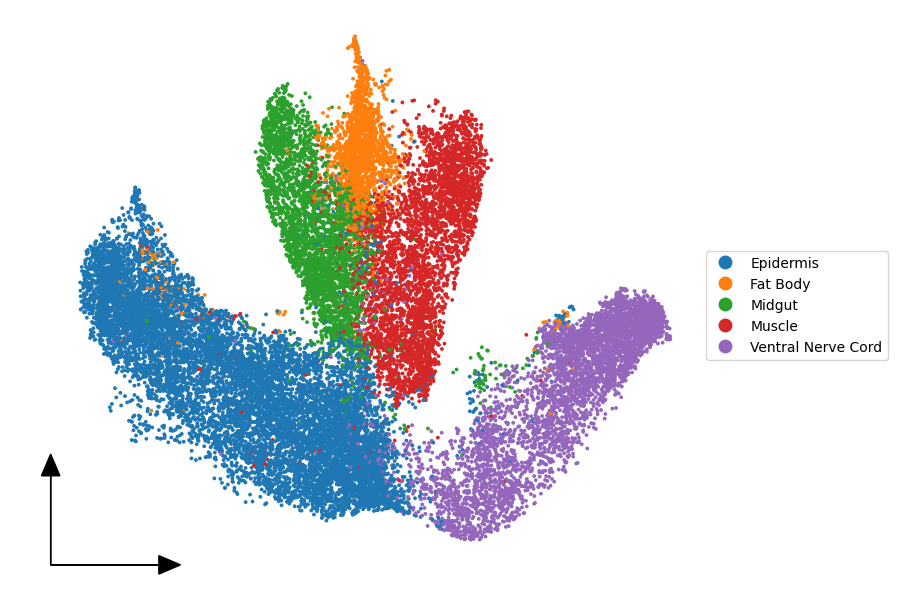

In [93]:
toolkit.pl.embedding2d(ctad2, 'X_umap', 'label_own')

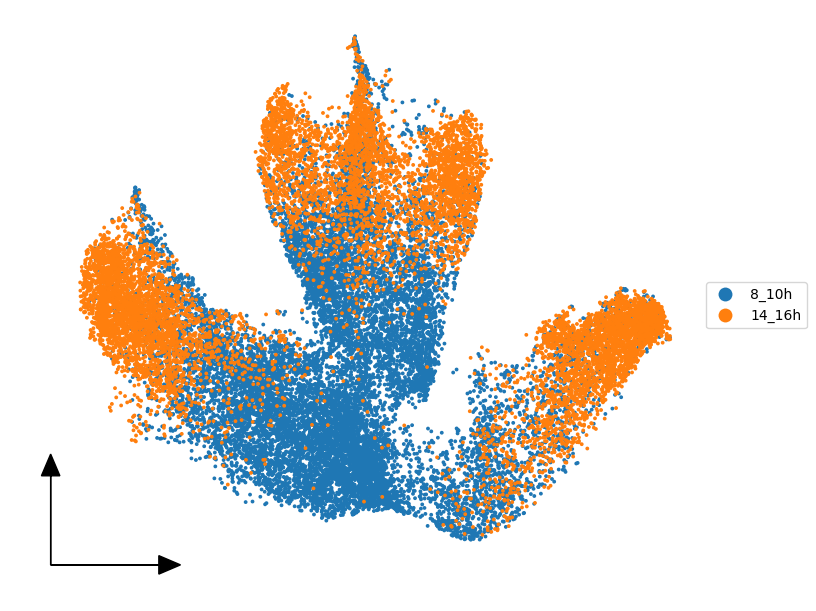

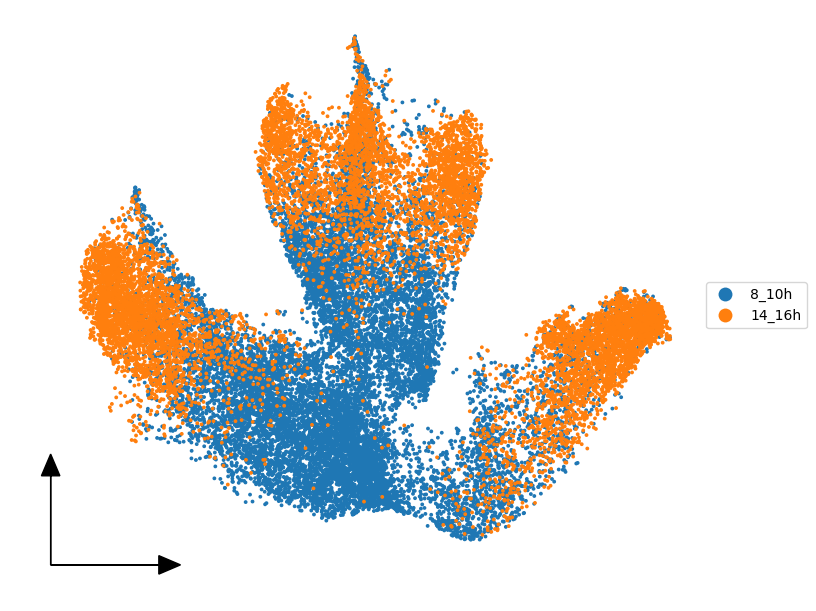

In [109]:
toolkit.pl.embedding2d(ctad2, 'X_umap', 'timep', show=False)

In [108]:
ctad2.uns['colors_dict']['8-10h'] = '#88CCEE'
ctad2.uns['colors_dict']['14_16h'] = '#322288'

In [105]:
ctad2.uns['colors_dict']

{'8_10h': '#1f77b4', '14_16h': '#ff7f0e'}

In [113]:
ic_meth = toolkit.tl.make_layer_config(
    'meth_binary',
    in_obsm=True,
    feature_names=ctad2.uns['gene_names_meth_binary'],
    feature_active_threshold=0
)
ic_acet = toolkit.tl.make_layer_config(
    'acet_binary',
    in_obsm=True,
    feature_names=ctad2.uns['gene_names_acet_binary'],
    feature_active_threshold=0
)

In [129]:
adata = ad.read_h5ad("../h5ad/ct_glue_postGO_anno_final_final_250310.h5ad")

In [130]:
adata

AnnData object with n_obs × n_vars = 26346 × 24130
    obs: 'batch', 'meth_total_counts', 'meth_log_total_counts', 'acet_total_counts', 'acet_log_total_counts', 'exclude', 'timep', 'leiden_ms', 'label', 'leiden_glue', 'acet_binary_total_counts', 'acet_binary_log_total_counts', 'meth_binary_total_counts', 'meth_binary_log_total_counts', 'imputed_acet_total_counts', 'imputed_acet_log_total_counts', 'imputed_meth_total_counts', 'imputed_meth_log_total_counts', 'copied_data', 'leiden', 'label_own', 'outside'
    var: 'acet_total_counts', 'acet_log_total_counts', 'meth_total_counts', 'meth_log_total_counts', 'acet_binary_total_counts', 'acet_binary_log_total_counts', 'meth_binary_total_counts', 'meth_binary_log_total_counts', 'imputed_acet_total_counts', 'imputed_acet_log_total_counts', 'imputed_meth_total_counts', 'imputed_meth_log_total_counts', 'chr', 'start', 'end'
    uns: 'colors_dict', 'gene_names_acet_binary', 'gene_names_acet_imp', 'gene_names_meth_binary', 'gene_names_meth_imp'
  

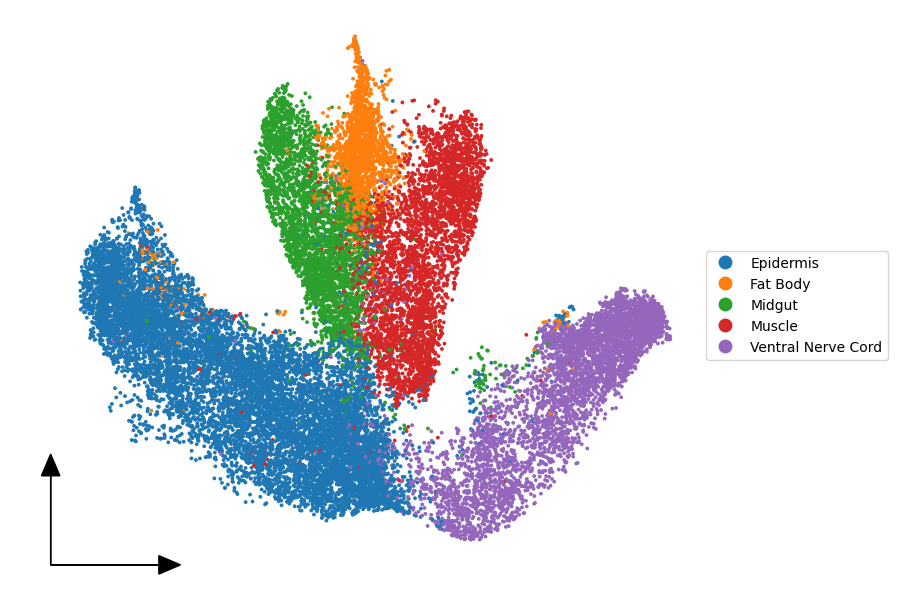

In [131]:
toolkit.pl.embedding2d(adata, 'X_umap', 'label_own')

In [132]:
ic_meth = toolkit.tl.make_layer_config(
    'meth_imp',
    in_obsm=True,
    feature_names=adata.uns['gene_names_meth_binary'],
    feature_active_threshold=0
)
ic_acet = toolkit.tl.make_layer_config(
    'acet_imp',
    in_obsm=True,
    feature_names=adata.uns['gene_names_acet_binary'],
    feature_active_threshold=0
)

In [149]:
from matplotlib import cm
from matplotlib.colors import LinearSegmentedColormap

def truncate_colormap(cmap, minval=0.2, maxval=0.8, n=100):
    new_cmap = LinearSegmentedColormap.from_list(
        f'trunc({cmap.name},{minval:.2f},{maxval:.2f})',
        cmap(np.linspace(minval, maxval, n))
    )
    return new_cmap

reds_trunc = truncate_colormap(cm.Reds, 0.2, 1.0)
blues_trunc = truncate_colormap(cm.Blues, 0.2, 1.0)

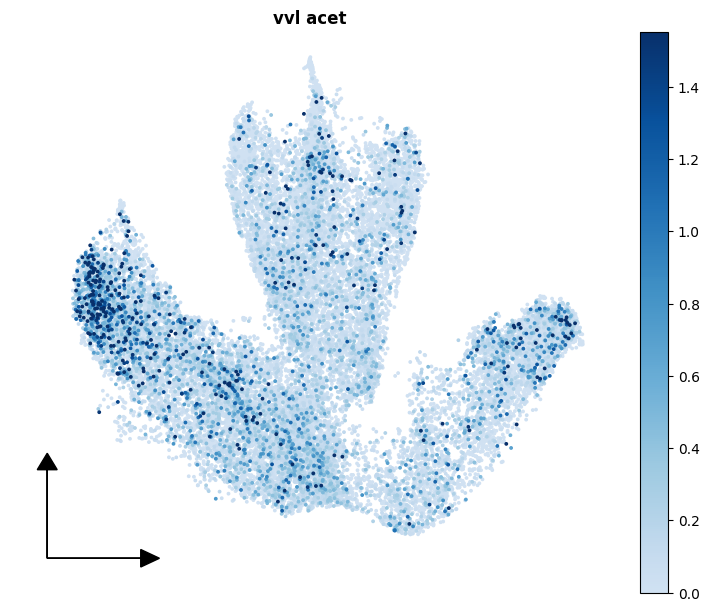

In [151]:
toolkit.tl.layer_pick_features(adata, ic_acet, 'vvl')
toolkit.tl.copy_to_obs(adata, ic_acet, binarize = False)
# toolkit.pl.embedding2d(ctad2, 'X_umap', 'label')
toolkit.pl.embedding2d(adata, 'X_umap', 'copied_data', cmap=blues_trunc,
                       vminmax= (0.0, np.quantile(adata.obs['copied_data'], q = 0.99)),
                       title = "vvl acet", black_background=False)

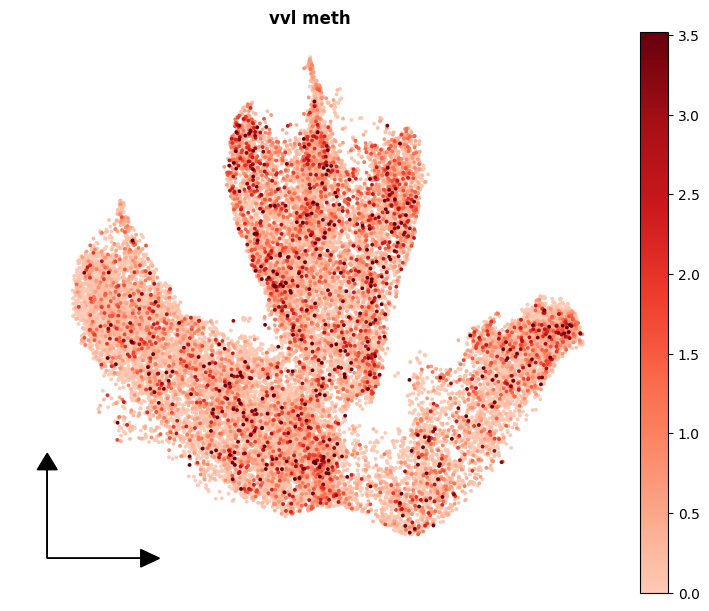

In [152]:
toolkit.tl.layer_pick_features(adata, ic_meth, 'vvl')
toolkit.tl.copy_to_obs(adata, ic_meth, binarize = False)
toolkit.pl.embedding2d(adata, 'X_umap', 'copied_data', cmap = reds_trunc,
                       vminmax= (0, np.quantile(adata.obs['copied_data'], q = 0.99)),
                       title = "vvl meth", black_background=False)